1.LOAD DATASET

In [11]:
import pandas as pd

PLATFORM = "Reddit"

train_df = pd.read_csv(
    "../data_preprocess/processed_data/ml_data/reddit_train.csv"
)

test_df = pd.read_csv(
    "../data_preprocess/processed_data/ml_data/reddit_test.csv"
)

print(train_df.shape)
print(test_df.shape)

(30068, 56)
(7517, 56)


In [2]:
X_train = train_df.drop(columns=["popularity"])
y_train = train_df["popularity"]

X_test = test_df.drop(columns=["popularity"])
y_test = test_df["popularity"]

In [3]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

model = XGBClassifier(

    # objective
    objective="binary:logistic",

    # evaluation metric
    eval_metric="logloss",

    # tree settings
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,

    # randomness
    random_state=42,

    # parallel processing
    n_jobs=-1
)

In [4]:
print("\n" + "=" * 60)
print("TRAINING XGBOOST...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)


TRAINING XGBOOST...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [5]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]


In [6]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [7]:
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      5983
           1       0.65      0.41      0.50      1534

    accuracy                           0.83      7517
   macro avg       0.76      0.68      0.70      7517
weighted avg       0.82      0.83      0.82      7517



In [8]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


CONFUSION MATRIX
[[5641  342]
 [ 904  630]]


In [9]:
importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 15 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(15)
)


TOP 15 IMPORTANT FEATURES
                feature  importance
3             followers    0.319311
42      language_Korean    0.022554
23        topic_Climate    0.020716
39      language_German    0.019335
28           topic_Food    0.018808
43  language_Portuguese    0.017881
29         topic_Gaming    0.017272
49        location_Asia    0.017271
22       topic_Business    0.017080
41    language_Japanese    0.016800
12             hour_cos    0.016114
30         topic_Health    0.016104
32        topic_Science    0.016055
10       toxicity_score    0.015979
52     location_Oceania    0.015960


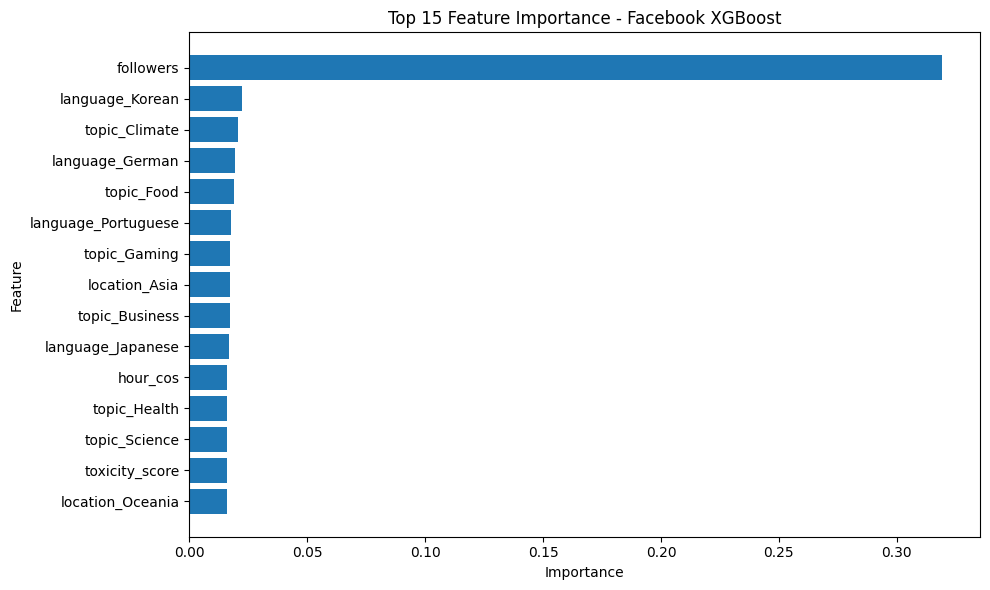

In [10]:
import matplotlib.pyplot as plt
top_n = 15

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Feature Importance - Facebook XGBoost"
)

plt.tight_layout()

plt.show()